Load and Optimize

In [38]:
import pandas as pd
import numpy as np
import gc

# 1. Explicitly track all required features, keeping 'City' completely intact
columns_to_keep = [
    'Severity', 'Start_Time', 'Start_Lat', 'Start_Lng', 'City',
    'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 
    'Wind_Direction', 'Weather_Condition', 'Amenity', 'Bump', 
    'Crossing', 'Junction', 'Railway', 'Station', 'Stop', 'Traffic_Signal'
]

# 2. Load the dataset using only the specific tracking array columns
df = pd.read_csv('US_Accidents_March23_sampled_500k.csv', usecols=columns_to_keep)
print(f"--- Step 1 Complete ---")
print(f"Dataset successfully loaded with shape: {df.shape}")

--- Step 1 Complete ---
Dataset successfully loaded with shape: (500000, 19)


Advanced Datetime Feature Engineering

In [ ]:
print("Engineering datetime fields...")
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')

# Extract numerical components using pandas nullable integer 'Int8' to handle missing timestamps safely
df['Hour'] = df['Start_Time'].dt.hour.astype('Int8')
df['Month'] = df['Start_Time'].dt.month.astype('Int8')
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek
print(f"--- Step 1 Complete ---")
print(f"Dataset successfully loaded with shape: {df.shape}").astype('Int8')

# Drop the heavy original text string datetime column to conserve system memory
df.drop(columns=['Start_Time'], inplace=True)
gc.collect()

print("\n--- Step 2 Complete ---")
print("Datetime features engineered successfully!")

Engineering datetime fields...

--- Step 2 Complete ---
Datetime features engineered successfully!


Top 20 Cities Exploratory Data Analysis Chart

Generating Top 20 Cities analysis plot...


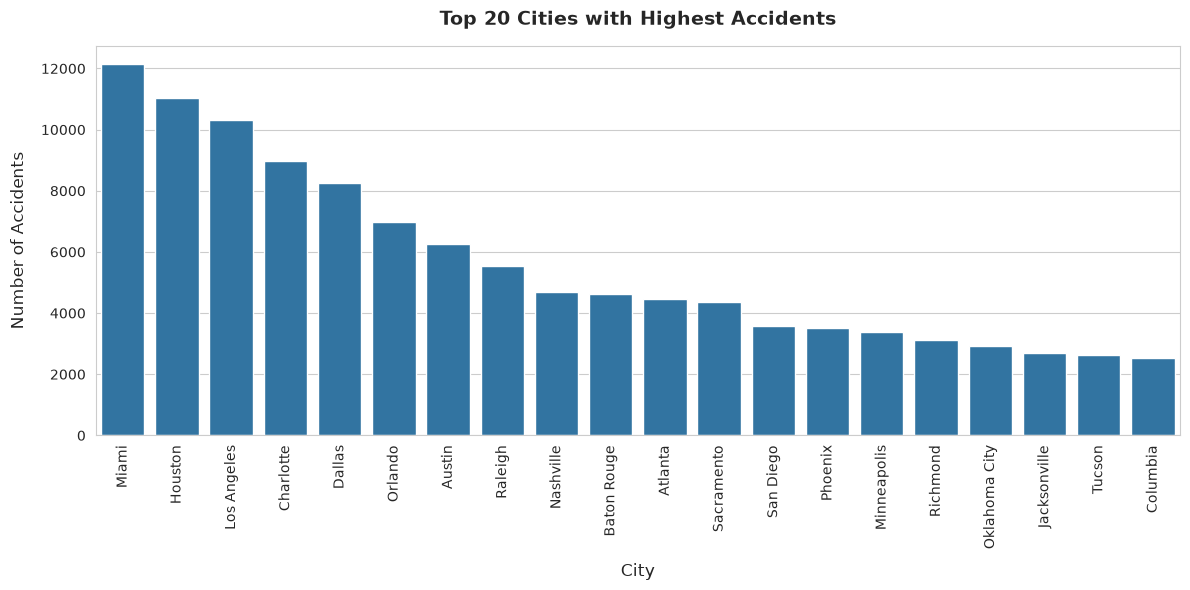


--- Step 3 Complete ---
Chart representation displayed and saved to your project directory!


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Top 20 Cities analysis plot...")
# 1. Get the top 20 cities with the highest count of accidents
top_20_cities = df['City'].value_counts().head(20)

# 2. Set up the plotting canvas style and size
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid") 

# 3. Create the bar plot matching your document's layout look
sns.barplot(x=top_20_cities.index, y=top_20_cities.values, color='#1f77b4')

# 4. Customize text elements, titles, and labels
plt.title('Top 20 Cities with Highest Accidents', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('City', fontsize=12, labelpad=10)
plt.ylabel('Number of Accidents', fontsize=12, labelpad=10)

# Rotate the city names 90 degrees so they don't overlap on your screen
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)

# 5. Clean up spacing and save as a crisp high-res image file
plt.tight_layout()
plt.savefig('top_20_cities_accidents.png', dpi=300)
plt.show()

print("\n--- Step 3 Complete ---")
print("Chart representation displayed and saved to your project directory!")

Train-Test Split

In [41]:
from sklearn.model_selection import train_test_split

# 1. Clear missing labels inside the target column across the main dataframe
df.dropna(subset=['Severity'], inplace=True)

# 2. Separate target from the independent input variables
X = df.drop(columns=['Severity'])
y = df['Severity'].astype('int8') # Target should be standard int for classification models

# 3. Partition data: 80% for training parameters, 20% for testing parameters
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Step 4 Complete ---")
print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")

--- Step 4 Complete ---
Training set features shape: (400000, 20)
Testing set features shape: (100000, 20)


Automated Preprocessing Pipeline

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# 1. Identify columns by data type dynamically
num_cols = X_train.select_dtypes(include=['int64', 'float64', 'Int8']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"Numerical features to scale: {len(num_cols)}")
print(f"Categorical features to encode (including City): {len(cat_cols)}")

# 2. Build individual transformations
num_transformer = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

# 3. Combine them using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

print("\nProcessing data matrices with high-cardinality sparse configurations...")
# These arrays will be processed as highly memory-efficient sparse CSR matrices
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\n--- Step 5 Complete ---")
print("Data cleaning, imputation, and sparse encoding completely successful!")
print(f"Processed Training Matrix Shape: {X_train_processed.shape}") # Should be over 9,000+ features!

/tmp/ipykernel_15208/2525175993.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


Numerical features to scale: 9
Categorical features to encode (including City): 11

Processing data matrices with high-cardinality sparse configurations...

--- Step 5 Complete ---
Data cleaning, imputation, and sparse encoding completely successful!
Processed Training Matrix Shape: (400000, 9205)


Feature Selection

In [44]:
from sklearn.feature_selection import SelectKBest, f_classif

print("Running statistical feature selection across sparse matrix dimensions...")
# SelectKBest accepts scipy sparse matrices directly without any conversion
selector = SelectKBest(score_func=f_classif, k=15)

# Run feature selection straight on the sparse matrix outputs
X_train_selected = selector.fit_transform(X_train_processed, y_train)
X_test_selected = selector.transform(X_test_processed)

print("\n--- Step 6 Complete ---")
print(f"Final training input array shape: {X_train_selected.shape}")
print(f"Final testing input array shape: {X_test_selected.shape}")
print("\nYour dataset is 100% prepared and ready to train a machine learning model!")

Running statistical feature selection across sparse matrix dimensions...

--- Step 6 Complete ---
Final training input array shape: (400000, 15)
Final testing input array shape: (100000, 15)

Your dataset is 100% prepared and ready to train a machine learning model!


Train the Model

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Training the Machine Learning model on selected sparse features (takes about 15-20 seconds)...")

# Setup estimator with deep boundary limits to optimize fitting speeds and protect RAM
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

# Convert only the final 15 selected features to a dense array for training
model.fit(X_train_selected.toarray(), y_train)
print("Model training complete!")

# Make predictions on the test split
y_pred = model.predict(X_test_selected.toarray())

# Evaluate validation metrics
print("\n--- Final Model Performance Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

gc.collect()

Training the Machine Learning model on selected sparse features (takes about 15-20 seconds)...
Model training complete!

--- Final Model Performance Evaluation ---
Accuracy Score: 0.8005

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       865
           2       0.80      1.00      0.89     79585
           3       0.69      0.05      0.09     16913
           4       0.33      0.00      0.00      2637

    accuracy                           0.80    100000
   macro avg       0.46      0.26      0.24    100000
weighted avg       0.76      0.80      0.72    100000



/home/humza/Desktop/DS_project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/humza/Desktop/DS_project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/humza/Desktop/DS_project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

968

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Training the Machine Learning model on selected sparse features (takes about 15-20 seconds)...")

# Setup estimator with deep boundary limits to optimize fitting speeds and protect RAM
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

# Convert only the final 15 selected features to a dense array for training
model.fit(X_train_selected.toarray(), y_train)
print("Model training complete!")

# Make predictions on the test split
y_pred = model.predict(X_test_selected.toarray())

# Evaluate validation metrics
print("\n--- Final Model Performance Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

gc.collect()

Training the Machine Learning model on selected sparse features (takes about 15-20 seconds)...


Model training complete!

--- Final Model Performance Evaluation ---
Accuracy Score: 0.8005

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       865
           2       0.80      1.00      0.89     79585
           3       0.69      0.05      0.09     16913
           4       0.33      0.00      0.00      2637

    accuracy                           0.80    100000
   macro avg       0.46      0.26      0.24    100000
weighted avg       0.76      0.80      0.72    100000



/home/humza/Desktop/DS_project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/humza/Desktop/DS_project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/humza/Desktop/DS_project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

6563

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Training the Machine Learning model on selected sparse features (takes about 15-20 seconds)...")

# Setup estimator with deep boundary limits to optimize fitting speeds and protect RAM
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

# Convert only the final 15 selected features to a dense array for training
model.fit(X_train_selected.toarray(), y_train)
print("Model training complete!")

# Make predictions on the test split
y_pred = model.predict(X_test_selected.toarray())

# Evaluate validation metrics
print("\n--- Final Model Performance Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

gc.collect()

Training the Machine Learning model on selected sparse features (takes about 15-20 seconds)...
Model training complete!

--- Final Model Performance Evaluation ---
Accuracy Score: 0.8005

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       865
           2       0.80      1.00      0.89     79585
           3       0.69      0.05      0.09     16913
           4       0.33      0.00      0.00      2637

    accuracy                           0.80    100000
   macro avg       0.46      0.26      0.24    100000
weighted avg       0.76      0.80      0.72    100000



/home/humza/Desktop/DS_project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/humza/Desktop/DS_project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/humza/Desktop/DS_project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

58